In [4]:

import numpy as np
import matplotlib.pyplot as plt 
plt.rc('font',family='Helvetica')
import os
from ADFWI.utils.assessment_metric import *

base_path = "examples/acoustic/02-misfit-functions-test/02-Marmousi2-Test2/data"

Envelope_path                   = os.path.join(base_path,"inversion-Envelope")
CG_path                         = os.path.join(base_path,"inversion-GC")
L1_path                         = os.path.join(base_path,"inversion-L1")
L2_path                         = os.path.join(base_path,"inversion-L2")
SmoothL1_path                   = os.path.join(base_path,"inversion-SmoothL1")
StudentT_path                   = os.path.join(base_path,"inversion-StudentT")
Softdtw_path                    = os.path.join(base_path,"inversion-SoftDTW")
Wasserstein_sinkhorn_path       = os.path.join(base_path,"inversion-Wasserstein_Sinkhorn")

layer = 88
show_model_idx = -1

# ad
L1_v_all                        = np.load(os.path.join(L1_path,"iter_vp.npz"))["data"][:,:layer,:]
SmoothL1_v_all                  = np.load(os.path.join(SmoothL1_path,"iter_vp.npz"))["data"][:,:layer,:]
L2_v_all                        = np.load(os.path.join(L2_path,"iter_vp.npz"))["data"][:,:layer,:]
StudentT_v_all                  = np.load(os.path.join(StudentT_path,"iter_vp.npz"))["data"][:,:layer,:]
CG_v_all                        = np.load(os.path.join(CG_path,"iter_vp.npz"))["data"][:,:layer,:]
Envelope_v_all                  = np.load(os.path.join(Envelope_path,"iter_vp.npz"))["data"][:,:layer,:]
Softdtw_v_all                   = np.load(os.path.join(Softdtw_path,"iter_vp.npz"))["data"][:,:layer,:]
Wasserstein_sinkhorn_v_all      = np.load(os.path.join(Wasserstein_sinkhorn_path,"iter_vp.npz"))["data"][:,:layer,:]

L1_v                            = L1_v_all[show_model_idx]
SmoothL1_v                      = SmoothL1_v_all[show_model_idx]
L2_v                            = L2_v_all[show_model_idx]
StudentT_v                      = StudentT_v_all[show_model_idx]
CG_v                            = CG_v_all[show_model_idx]
Envelope_v                      = Envelope_v_all[show_model_idx]
Softdtw_v                       = Softdtw_v_all[show_model_idx]
Wasserstein_sinkhorn_v          = Wasserstein_sinkhorn_v_all[show_model_idx]

# misfit 
L1_data_loss                    = np.load(os.path.join(L1_path,"iter_loss.npz"))["data"]
SmoothL1_data_loss              = np.load(os.path.join(SmoothL1_path,"iter_loss.npz"))["data"]
L2_data_loss                    = np.load(os.path.join(L2_path,"iter_loss.npz"))["data"]
StudentT_data_loss              = np.load(os.path.join(StudentT_path,"iter_loss.npz"))["data"]
CG_data_loss                    = np.load(os.path.join(CG_path,"iter_loss.npz"))["data"]
Envelope_data_loss              = np.load(os.path.join(Envelope_path,"iter_loss.npz"))["data"]
Softdtw_data_loss               = np.load(os.path.join(Softdtw_path,"iter_loss.npz"))["data"]
Wasserstein_sinkhorn_data_loss  = np.load(os.path.join(Wasserstein_sinkhorn_path,"iter_loss.npz"))["data"]

In [5]:
init_model      = np.load(os.path.join(base_path,"model/init_model.npz"))
true_model      = np.load(os.path.join(base_path,"model/true_model.npz"))
init_v          = init_model["vp"][:layer,:]
true_v          = true_model["vp"][:layer,:]

## MAPE

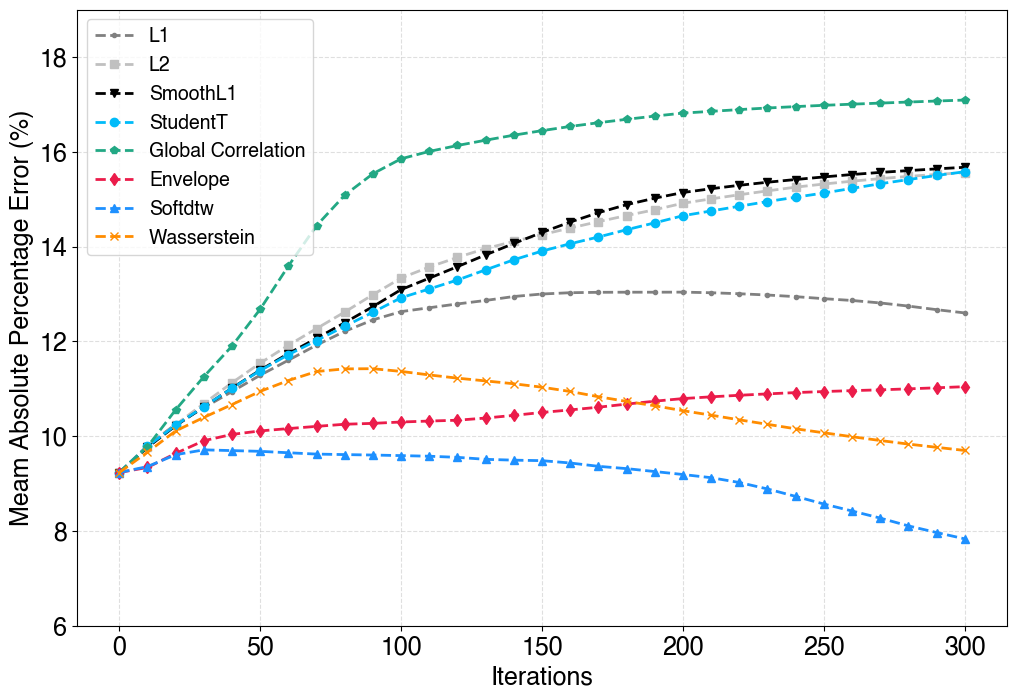

In [28]:
init_model_loss                  =           MAPE(true_v,init_v)
L1_model_loss                    = np.insert(MAPE(true_v,L1_v_all),0,init_model_loss)
SmoothL1_model_loss              = np.insert(MAPE(true_v,SmoothL1_v_all),0,init_model_loss)
L2_model_loss                    = np.insert(MAPE(true_v,L2_v_all),0,init_model_loss)
StudentT_model_loss              = np.insert(MAPE(true_v,StudentT_v_all),0,init_model_loss)
Envelope_model_loss              = np.insert(MAPE(true_v,Envelope_v_all),0,init_model_loss)
CG_model_loss                    = np.insert(MAPE(true_v,CG_v_all),0,init_model_loss)
Softdtw_model_loss               = np.insert(MAPE(true_v,Softdtw_v_all),0,init_model_loss)
Wasserstein_sinkhorn_model_loss  = np.insert(MAPE(true_v,Wasserstein_sinkhorn_v_all),0,init_model_loss)


plt.figure(figsize=(12,8))
x_lists = np.arange(len(L1_model_loss))
x_space = 10
# colors: https://zhuanlan.zhihu.com/p/689959306
plt.plot(x_lists[::x_space],L1_model_loss[::x_space]             ,label="L1"                ,c='gray'     ,linestyle='--' ,marker=".",linewidth=2)
plt.plot(x_lists[::x_space],L2_model_loss[::x_space]             ,label="L2"                ,c='silver'   ,linestyle='--' ,marker="s",linewidth=2)
plt.plot(x_lists[::x_space],SmoothL1_model_loss[::x_space]       ,label="SmoothL1"          ,c='k'        ,linestyle='--' ,marker="v",linewidth=2)
plt.plot(x_lists[::x_space],StudentT_model_loss[::x_space]       ,label="StudentT"          ,c='#00BBF9'  ,linestyle='--' ,marker="o",linewidth=2)
plt.plot(x_lists[::x_space],CG_model_loss[::x_space]             ,label="Global Correlation",c='#22A884'  ,linestyle='--' ,marker="p",linewidth=2)
plt.plot(x_lists[::x_space],Envelope_model_loss[::x_space]       ,label="Envelope"          ,c='#EB1C4A'  ,linestyle='--' ,marker="d",linewidth=2)
plt.plot(x_lists[::x_space],Softdtw_model_loss[::x_space]        ,label="Softdtw"           ,c='#1E90FF'  ,linestyle='--' ,marker="^",linewidth=2)
plt.plot(x_lists[::x_space],Wasserstein_sinkhorn_model_loss[::x_space]   ,label="Wasserstein"       ,c='#FF8C00'  ,linestyle='--' ,marker="x",linewidth=2)
plt.grid(linestyle="--",c="silver",alpha=0.5)

plt.ylim(6,19)
plt.xlabel("Iterations",fontsize=18)
plt.ylabel("Meam Absolute Percentage Error (%)",fontsize=18)
plt.tick_params(labelsize=18)
plt.legend(fontsize=14)
plt.savefig(os.path.join(base_path,"MisfitTest_MAPE.png"),dpi=300,bbox_inches='tight')
plt.show()

In [29]:
print(f"L1 MAPE                         :{MAPE(true_v,L1_v):.3f}")
print(f"Smooth L1 MAPE                  :{MAPE(true_v,SmoothL1_v):.3f}")
print(f"L2 MAPE                         :{MAPE(true_v,L2_v):.3f}")
print(f"StudentT MAPE                   :{MAPE(true_v,StudentT_v):.3f}")
print(f"Global Correlation MAPE         :{MAPE(true_v,CG_v):.3f}")
print(f"Envelope MAPE                   :{MAPE(true_v,Envelope_v):.3f}")
print(f"Soft-DTW MAPE                   :{MAPE(true_v,Softdtw_v):.3f}")
print(f"Wasserstein Sinkhorn MAPE       :{MAPE(true_v,Wasserstein_sinkhorn_v):.3f}")

print(f"{MAPE(true_v,L1_v):.3f}\t{MAPE(true_v,L2_v):.3f}\t{MAPE(true_v,StudentT_v):.3f}\t{MAPE(true_v,CG_v):.3f}\t{MAPE(true_v,Envelope_v):.3f}\t{MAPE(true_v,Softdtw_v):.3f}\t{MAPE(true_v,Wasserstein_sinkhorn_v):.3f}\t")

L1 MAPE                         :12.601
Smooth L1 MAPE                  :15.675
L2 MAPE                         :15.563
StudentT MAPE                   :15.581
Global Correlation MAPE         :17.094
Envelope MAPE                   :11.045
Soft-DTW MAPE                   :7.833
Wasserstein Sinkhorn MAPE       :9.699
12.601	15.563	15.581	17.094	11.045	7.833	9.699	


## SSIM

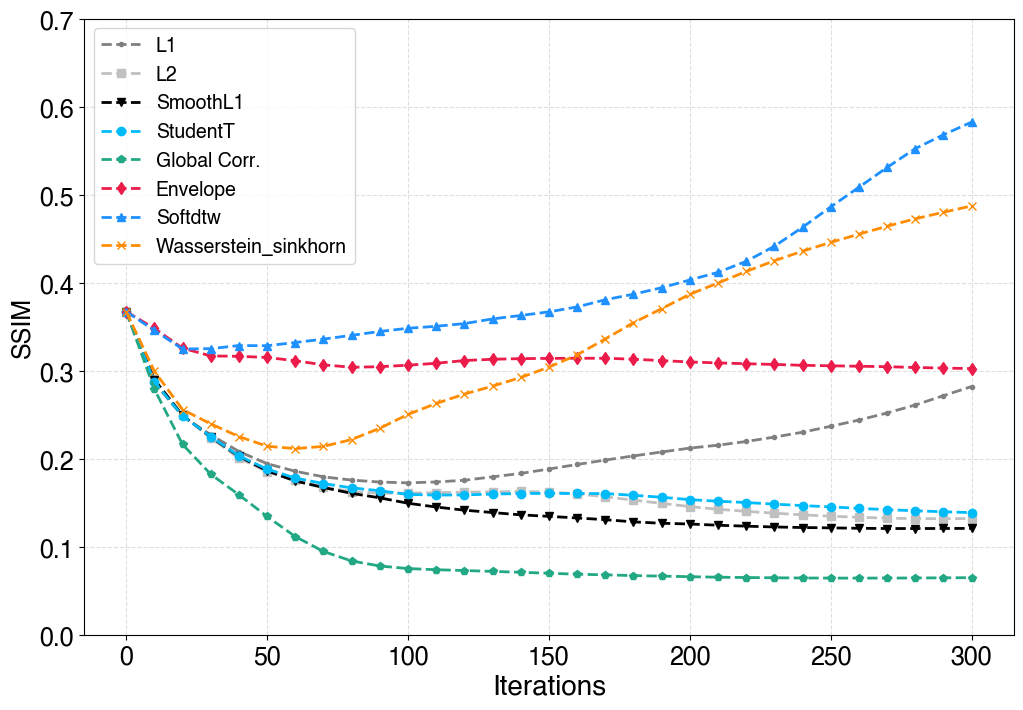

In [30]:
init_model_ssim_loss                =           SSIM(true_v,init_v)
L1_model_ssim_loss                  = np.insert(SSIM(true_v,L1_v_all),0,init_model_ssim_loss)
SmoothL1_model_ssim_loss            = np.insert(SSIM(true_v,SmoothL1_v_all),0,init_model_ssim_loss)
L2_model_ssim_loss                  = np.insert(SSIM(true_v,L2_v_all),0,init_model_ssim_loss)
StudentT_model_ssim_loss            = np.insert(SSIM(true_v,StudentT_v_all),0,init_model_ssim_loss)
Envelope_model_ssim_loss            = np.insert(SSIM(true_v,Envelope_v_all),0,init_model_ssim_loss)
CG_model_ssim_loss                  = np.insert(SSIM(true_v,CG_v_all),0,init_model_ssim_loss)
Softdtw_model_ssim_loss             = np.insert(SSIM(true_v,Softdtw_v_all),0,init_model_ssim_loss)
Wasserstein_sinkhorn_model_ssim_loss= np.insert(SSIM(true_v,Wasserstein_sinkhorn_v_all),0,init_model_ssim_loss)

plt.figure(figsize=(12,8))
x_lists = np.arange(len(L1_model_loss))
x_space = 10
# colors: https://zhuanlan.zhihu.com/p/689959306
plt.plot(x_lists[::x_space],L1_model_ssim_loss[::x_space]                     ,label="L1"                     ,c='gray'     ,linestyle='--' ,marker=".",linewidth=2)
plt.plot(x_lists[::x_space],L2_model_ssim_loss[::x_space]                     ,label="L2"                     ,c='silver'   ,linestyle='--' ,marker="s",linewidth=2)
plt.plot(x_lists[::x_space],SmoothL1_model_ssim_loss[::x_space]               ,label="SmoothL1"               ,c='k'        ,linestyle='--' ,marker="v",linewidth=2)
plt.plot(x_lists[::x_space],StudentT_model_ssim_loss[::x_space]               ,label="StudentT"               ,c='#00BBF9'  ,linestyle='--' ,marker="o",linewidth=2)
plt.plot(x_lists[::x_space],CG_model_ssim_loss[::x_space]                     ,label="Global Corr."           ,c='#22A884'  ,linestyle='--' ,marker="p",linewidth=2)
plt.plot(x_lists[::x_space],Envelope_model_ssim_loss[::x_space]               ,label="Envelope"               ,c='#EB1C4A'  ,linestyle='--' ,marker="d",linewidth=2)
plt.plot(x_lists[::x_space],Softdtw_model_ssim_loss[::x_space]                ,label="Softdtw"                ,c='#1E90FF'  ,linestyle='--' ,marker="^",linewidth=2)
plt.plot(x_lists[::x_space],Wasserstein_sinkhorn_model_ssim_loss[::x_space]   ,label="Wasserstein_sinkhorn"   ,c='#FF8C00'  ,linestyle='--' ,marker="x",linewidth=2)
plt.grid(linestyle="--",c="silver",alpha=0.5)
# plt.yscale("log",base=2,subs=[2,3])
plt.ylim(0,0.7)
plt.xlabel("Iterations",fontsize=20)
plt.ylabel("SSIM",fontsize=18)
plt.tick_params(labelsize=18)
plt.legend(fontsize=14,loc='upper left')
plt.savefig(os.path.join(base_path,"MisfitTest_SSIM.png"),dpi=300,bbox_inches='tight')
plt.show()

## SNR

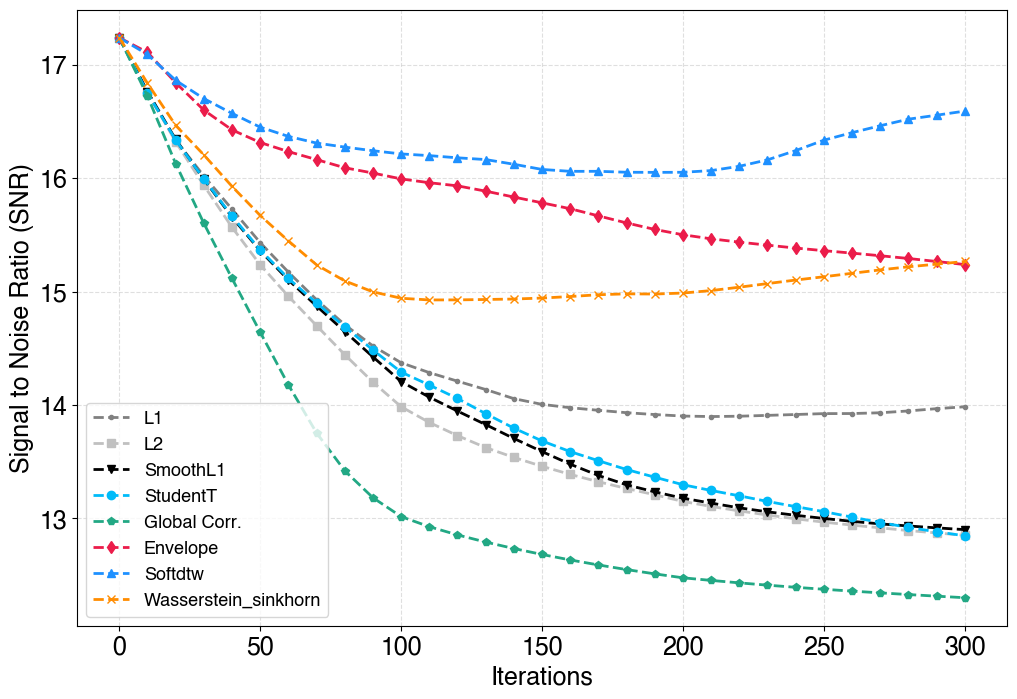

In [14]:
init_model_snr_loss        =           SNR(true_v,init_v)
L1_model_snr_loss          = np.insert(SNR(true_v,L1_v_all),0       ,init_model_snr_loss)
SmoothL1_model_snr_loss    = np.insert(SNR(true_v,SmoothL1_v_all),0  ,init_model_snr_loss)
L2_model_snr_loss          = np.insert(SNR(true_v,L2_v_all),0       ,init_model_snr_loss)
StudentT_model_snr_loss    = np.insert(SNR(true_v,StudentT_v_all),0 ,init_model_snr_loss)
Envelope_model_snr_loss    = np.insert(SNR(true_v,Envelope_v_all),0 ,init_model_snr_loss)
CG_model_snr_loss          = np.insert(SNR(true_v,CG_v_all),0       ,init_model_snr_loss)
Softdtw_model_snr_loss     = np.insert(SNR(true_v,Softdtw_v_all),0  ,init_model_snr_loss)
Wasserstein_sinkhorn_model_snr_loss= np.insert(SNR(true_v,Wasserstein_sinkhorn_v_all),0,init_model_snr_loss)

plt.figure(figsize=(12,8))
x_lists = np.arange(len(L1_model_loss))
x_space = 10
# colors: https://zhuanlan.zhihu.com/p/689959306
plt.plot(x_lists[::x_space],L1_model_snr_loss[::x_space]             ,label="L1"             ,c='gray'     ,linestyle='--' ,marker=".",linewidth=2)
plt.plot(x_lists[::x_space],L2_model_snr_loss[::x_space]             ,label="L2"             ,c='silver'   ,linestyle='--' ,marker="s",linewidth=2)
plt.plot(x_lists[::x_space],SmoothL1_model_snr_loss[::x_space]       ,label="SmoothL1"       ,c='k'        ,linestyle='--' ,marker="v",linewidth=2)
plt.plot(x_lists[::x_space],StudentT_model_snr_loss[::x_space]       ,label="StudentT"       ,c='#00BBF9'  ,linestyle='--' ,marker="o",linewidth=2)
plt.plot(x_lists[::x_space],CG_model_snr_loss[::x_space]             ,label="Global Corr."   ,c='#22A884'  ,linestyle='--' ,marker="p",linewidth=2)
plt.plot(x_lists[::x_space],Envelope_model_snr_loss[::x_space]       ,label="Envelope"       ,c='#EB1C4A'  ,linestyle='--' ,marker="d",linewidth=2)
plt.plot(x_lists[::x_space],Softdtw_model_snr_loss[::x_space]        ,label="Softdtw"        ,c='#1E90FF'  ,linestyle='--' ,marker="^",linewidth=2)
plt.plot(x_lists[::x_space],Wasserstein_sinkhorn_model_snr_loss[::x_space]   ,label="Wasserstein_sinkhorn"   ,c='#FF8C00'  ,linestyle='--' ,marker="x",linewidth=2)
plt.grid(linestyle="--",c="silver",alpha=0.5)
# plt.yscale("log",base=2,subs=[2,3])
# plt.ylim(12,18)

plt.xlabel("Iterations",fontsize=18)
plt.ylabel("Signal to Noise Ratio (SNR)",fontsize=18)
plt.tick_params(labelsize=18)
plt.legend(fontsize=13,loc='lower left')
# plt.savefig(os.path.join(base_path,"./Article-Figure/Figure_7_MisfitTest_SNR.png"),dpi=300,bbox_inches='tight')
plt.show()

In [16]:
print(f"L1 SRN                  :{SNR(true_v,L1_v):.5f}")
print(f"SmoothL1 SRN            :{SNR(true_v,SmoothL1_v):.5f}")
print(f"L2 SNR                  :{SNR(true_v,L2_v):.5f}")
print(f"StudentT SNR            :{SNR(true_v,StudentT_v):.5f}")
print(f"Global Correlation SNR  :{SNR(true_v,CG_v):.5f}")
print(f"Envelope SNR            :{SNR(true_v,Envelope_v):.5f}")
print(f"Soft-DTW SNR            :{SNR(true_v,Softdtw_v):.5f}")
print(f"Wasserstein_sinkhorn SNR:{SNR(true_v,Wasserstein_sinkhorn_v):.5f}")


print(f"{SNR(true_v,L1_v):.3f}\t{SNR(true_v,L2_v):.3f}\t{SNR(true_v,StudentT_v):.3f}\t{SNR(true_v,CG_v):.3f}\t{SNR(true_v,Envelope_v):.3f}\t{SNR(true_v,Softdtw_v):.3f}\t{SNR(true_v,Wasserstein_sinkhorn_v):.3f}\t")

L1 SRN                  :13.98418
SmoothL1 SRN            :12.90167
L2 SNR                  :12.85157
StudentT SNR            :12.84770
Global Correlation SNR  :12.30172
Envelope SNR            :15.23742
Soft-DTW SNR            :16.58964
Wasserstein_sinkhorn SNR:15.26443
13.984	12.852	12.848	12.302	15.237	16.590	15.264	


## inversion Result

In [17]:
ox,oz = 0,0
nz,nx = 88,200
dx,dz = 40, 40
nt,dt = 1600, 0.003
nabc  = 30
f0    = 5
free_surface = True
x = np.arange(nx)*dx/1000
z = np.arange(nz)*dz/1000
x_mesh,z_mesh = np.meshgrid(x,z)
src_z = np.array([1  for i in range(1,nx-1,5)])*dz/1000
src_x = np.array([i  for i in range(1,nx-1,5)])*dx/1000
rcv_z = np.array([1  for i in range(0,nx-1,1)])*dz/1000
rcv_x = np.array([j  for j in range(0,nx-1,1)])*dz/1000
vmin = true_v.min();vmax = true_v.max()

def plot_vel_single_for_all(fig,ax,v,title="",MSE=""):
    plt.rc('font',family='Helvetica')
    # cmap = "jet_r"
    cmap = "rainbow"
    # plm = ax.pcolormesh(x_mesh, z_mesh, v,cmap=cmap,vmin=vmin,vmax=vmax)
    x = np.arange(nx*3)*dx/3/1000
    z = np.arange(nz*3)*dz/3/1000
    x_mesh_new,z_mesh_new = np.meshgrid(x,z)
    from scipy.interpolate import griddata
    v_new = griddata((x_mesh.flatten(), z_mesh.flatten()), v.flatten(), (x_mesh_new, z_mesh_new), method='cubic')
    
    plm = ax.pcolormesh(x_mesh_new, z_mesh_new, v_new,cmap=cmap,vmin=vmin,vmax=vmax,shading="nearest")
    ax.invert_yaxis()
    ax.tick_params(labelsize = 16)
    ax.set_title(title,fontsize=16)
    ax.text(5.2,0.35,MSE,fontsize=16,c="w")
    return plm

import matplotlib.transforms as mtransforms
def add_right_cax(ax, pad, width):
    '''
    在一个ax右边追加与之等高的cax.
    pad是cax与ax的间距,width是cax的宽度.
    '''
    axpos = ax.get_position()
    caxpos = mtransforms.Bbox.from_extents(
        axpos.x1 + pad,
        axpos.y0,
        axpos.x1 + pad + width,
        axpos.y1
    )
    cax = ax.figure.add_axes(caxpos)

    return cax

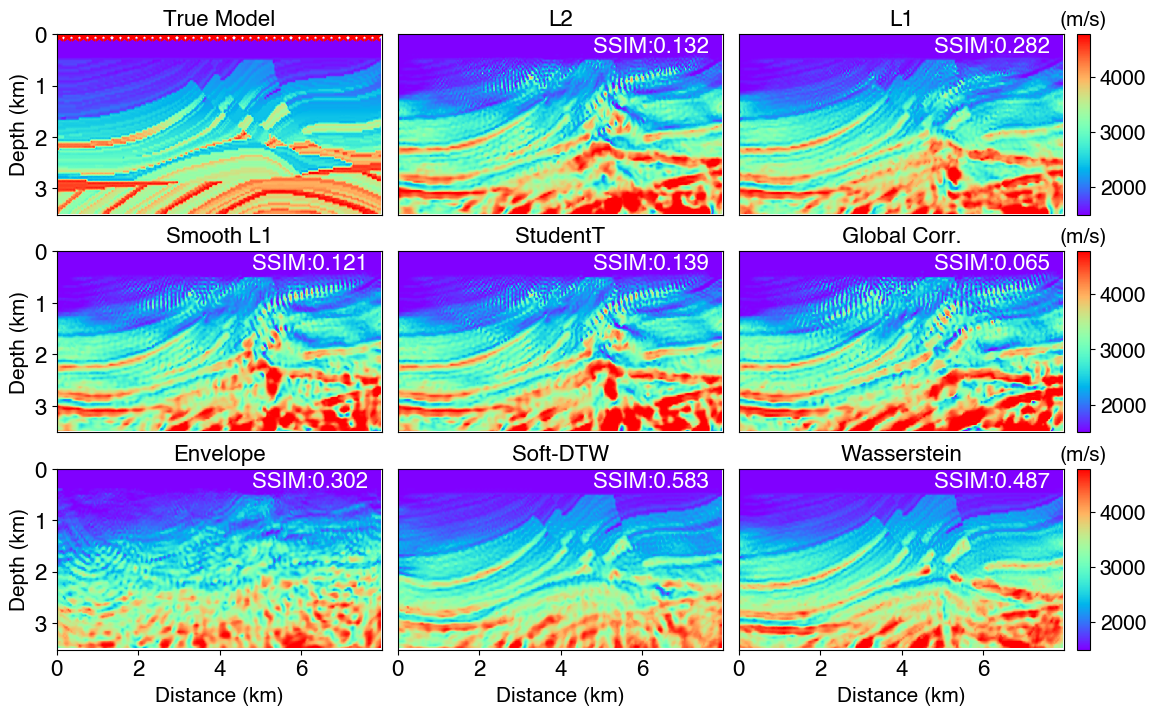

In [21]:
import matplotlib.pyplot as plt
from matplotlib import gridspec

def plot_vel_single_for_all(fig,ax,v,title="",MSE=""):
    plt.rc('font',family='Helvetica')
    # cmap = "bwr"
    cmap = "rainbow"
    # plm = ax.pcolormesh(x_mesh, z_mesh, v,cmap=cmap,vmin=vmin,vmax=vmax)
    x = np.arange(nx*3)*dx/3/1000
    z = np.arange(nz*3)*dz/3/1000
    x_mesh_new,z_mesh_new = np.meshgrid(x,z)
    from scipy.interpolate import griddata
    v_new = griddata((x_mesh.flatten(), z_mesh.flatten()), v.flatten(), (x_mesh_new, z_mesh_new), method='cubic')
    
    plm = ax.pcolormesh(x_mesh_new, z_mesh_new, v_new,cmap=cmap,vmin=vmin,vmax=vmax,shading="nearest")
    ax.invert_yaxis()
    ax.tick_params(labelsize = 16)
    ax.set_title(title,fontsize=16)
    ax.text(4.8,0.35,MSE,fontsize=16,c="w")
    return plm

import matplotlib.transforms as mtransforms
def add_right_cax(ax, pad, width):
    '''
    在一个ax右边追加与之等高的cax.
    pad是cax与ax的间距,width是cax的宽度.
    '''
    axpos = ax.get_position()
    caxpos = mtransforms.Bbox.from_extents(
        axpos.x1 + pad,
        axpos.y0,
        axpos.x1 + pad + width,
        axpos.y1
    )
    cax = ax.figure.add_axes(caxpos)

    return cax

fig = plt.figure(figsize = (13,8))
gs  = gridspec.GridSpec(3,6,hspace=0.2)
ax11 = fig.add_subplot(gs[0,0:2])
ax12 = fig.add_subplot(gs[0,2:4])
ax13 = fig.add_subplot(gs[0,4:6])
ax21 = fig.add_subplot(gs[1,0:2])
ax22 = fig.add_subplot(gs[1,2:4])
ax23 = fig.add_subplot(gs[1,4:6])
ax31 = fig.add_subplot(gs[2,0:2])
ax32 = fig.add_subplot(gs[2,2:4])
ax33 = fig.add_subplot(gs[2,4:6])

im = plot_vel_single_for_all(fig,ax11,true_v     ,title="True Model")
plot_vel_single_for_all(fig,ax12,L2_v            ,title="L2"                    ,MSE="SSIM:{:.3f}".format(SSIM(true_v,L2_v,win_size=11)))
plot_vel_single_for_all(fig,ax13,L1_v            ,title="L1"                    ,MSE="SSIM:{:.3f}".format(SSIM(true_v,L1_v,win_size=11)))
plot_vel_single_for_all(fig,ax21,SmoothL1_v      ,title="Smooth L1"             ,MSE="SSIM:{:.3f}".format(SSIM(true_v,SmoothL1_v,win_size=11)))
plot_vel_single_for_all(fig,ax22,StudentT_v      ,title="StudentT"              ,MSE="SSIM:{:.3f}".format(SSIM(true_v,StudentT_v,win_size=11)))
plot_vel_single_for_all(fig,ax23,CG_v            ,title="Global Corr."          ,MSE="SSIM:{:.3f}".format(SSIM(true_v,CG_v,win_size=11)))
plot_vel_single_for_all(fig,ax31,Envelope_v      ,title="Envelope"              ,MSE="SSIM:{:.3f}".format(SSIM(true_v,Envelope_v,win_size=11)))
plot_vel_single_for_all(fig,ax32,Softdtw_v        ,title="Soft-DTW"             ,MSE="SSIM:{:.3f}".format(SSIM(true_v,Softdtw_v,win_size=11)))
plot_vel_single_for_all(fig,ax33,Wasserstein_sinkhorn_v ,title="Wasserstein"    ,MSE="SSIM:{:.3f}".format(SSIM(true_v,Wasserstein_sinkhorn_v,win_size=11)))

# colorbar
cax1 = add_right_cax(ax13,pad=0.01,width=0.01)
cbar1 = fig.colorbar(im, cax=cax1)
cbar1.ax.set_title("(m/s)",fontsize=15,loc='center')
cbar1.ax.tick_params(labelsize=15)
cax2 = add_right_cax(ax23,pad=0.01,width=0.01)
cbar2 = fig.colorbar(im, cax=cax2)
cbar2.ax.set_title("(m/s)",fontsize=15,loc='center')
cbar2.ax.tick_params(labelsize=15)
cax3 = add_right_cax(ax33,pad=0.01,width=0.01)
cbar3 = fig.colorbar(im, cax=cax3)
cbar3.ax.set_title("(m/s)",fontsize=15,loc='center')
cbar3.ax.tick_params(labelsize=15)

ax11.scatter(rcv_x,rcv_z,c="w",marker="v",s=10)
ax11.scatter(src_x,src_z,c="r",marker="*",s=60)
ax11.set_ylabel("Depth (km)",fontsize=15)
ax21.set_ylabel("Depth (km)",fontsize=15)
ax31.set_ylabel("Depth (km)",fontsize=15)
ax31.set_xlabel("Distance (km)",fontsize=15)
ax32.set_xlabel("Distance (km)",fontsize=15)
ax33.set_xlabel("Distance (km)",fontsize=15)

ax11.set_xticks([])
ax12.set_xticks([])
ax13.set_xticks([])
ax21.set_xticks([])
ax22.set_xticks([])
ax23.set_xticks([])
ax12.set_yticks([])
ax13.set_yticks([])
ax22.set_yticks([])
ax23.set_yticks([])
ax32.set_yticks([])
ax33.set_yticks([])

plt.subplots_adjust(hspace=0.2,wspace=0.1)

plt.savefig(os.path.join(base_path,"TestWithDiffMisfit.png"),dpi=300,bbox_inches='tight')
plt.show()

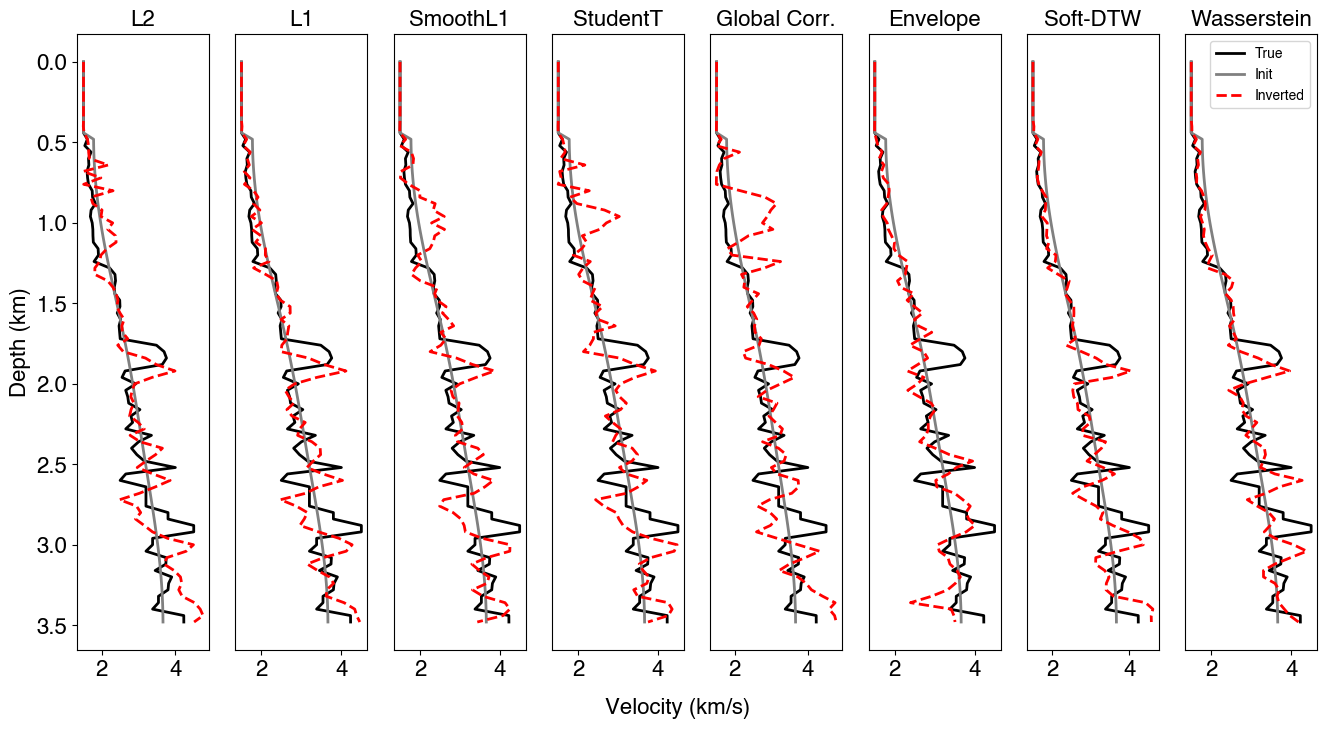

In [24]:
def plot_vel_singleline_for_all(ax,v_true,v_init,v_inv,x_distance,title,show_xlabel=True,show_ylabel=False,show_legend=False):
    ax.plot(v_true[:,int(x_distance//dx)]/1000,  z, c='k',   linewidth=2, linestyle="-" ,label="True")
    ax.plot(v_init[:,int(x_distance//dx)]/1000,  z, c='gray',linewidth=2, linestyle="-" ,label="Init")
    ax.plot(v_inv [:,int(x_distance//dx)]/1000,  z, c='r',   linewidth=2, linestyle="--",label="Inverted")
    ax.tick_params(labelsize = 16)
    if not show_xlabel:
        ax.set_xticks([])
        
    if not show_ylabel:
        ax.set_yticks([])
    else:
        ax.tick_params(labelsize = 16)
    ax.invert_yaxis()
    
    if show_legend:
        ax.legend(fontsize = 10)
    ax.set_title(title,fontsize=16)

fig,axs = plt.subplots(1,8,figsize=(16,8))
x_distance = 2500
plot_vel_singleline_for_all(axs[0],true_v,init_v,L2_v                   ,x_distance=x_distance,title=r"L2"          , show_ylabel=True )
plot_vel_singleline_for_all(axs[1],true_v,init_v,L1_v                   ,x_distance=x_distance,title=r"L1"          , show_ylabel=False)
plot_vel_singleline_for_all(axs[2],true_v,init_v,SmoothL1_v             ,x_distance=x_distance,title=r"SmoothL1"    , show_ylabel=False)
plot_vel_singleline_for_all(axs[3],true_v,init_v,StudentT_v             ,x_distance=x_distance,title=r"StudentT"    , show_ylabel=False)
plot_vel_singleline_for_all(axs[4],true_v,init_v,CG_v                   ,x_distance=x_distance,title=r"Global Corr.", show_ylabel=False)
plot_vel_singleline_for_all(axs[5],true_v,init_v,Envelope_v             ,x_distance=x_distance,title=r"Envelope"    , show_ylabel=False)
plot_vel_singleline_for_all(axs[6],true_v,init_v,Softdtw_v              ,x_distance=x_distance,title=r"Soft-DTW"    , show_ylabel=False)
plot_vel_singleline_for_all(axs[7],true_v,init_v,Wasserstein_sinkhorn_v ,x_distance=x_distance,title=r"Wasserstein", show_ylabel=False,show_legend=True)

axs[0].set_ylabel("Depth (km)",fontsize=16)
fig.text(0.5, 0.03, 'Velocity (km/s)', ha='center',fontsize=16)

plt.savefig(os.path.join(base_path,"TestWithDiffMisfit-smooth=12-xdistance=2500.png"),dpi=300,bbox_inches='tight')
plt.show()

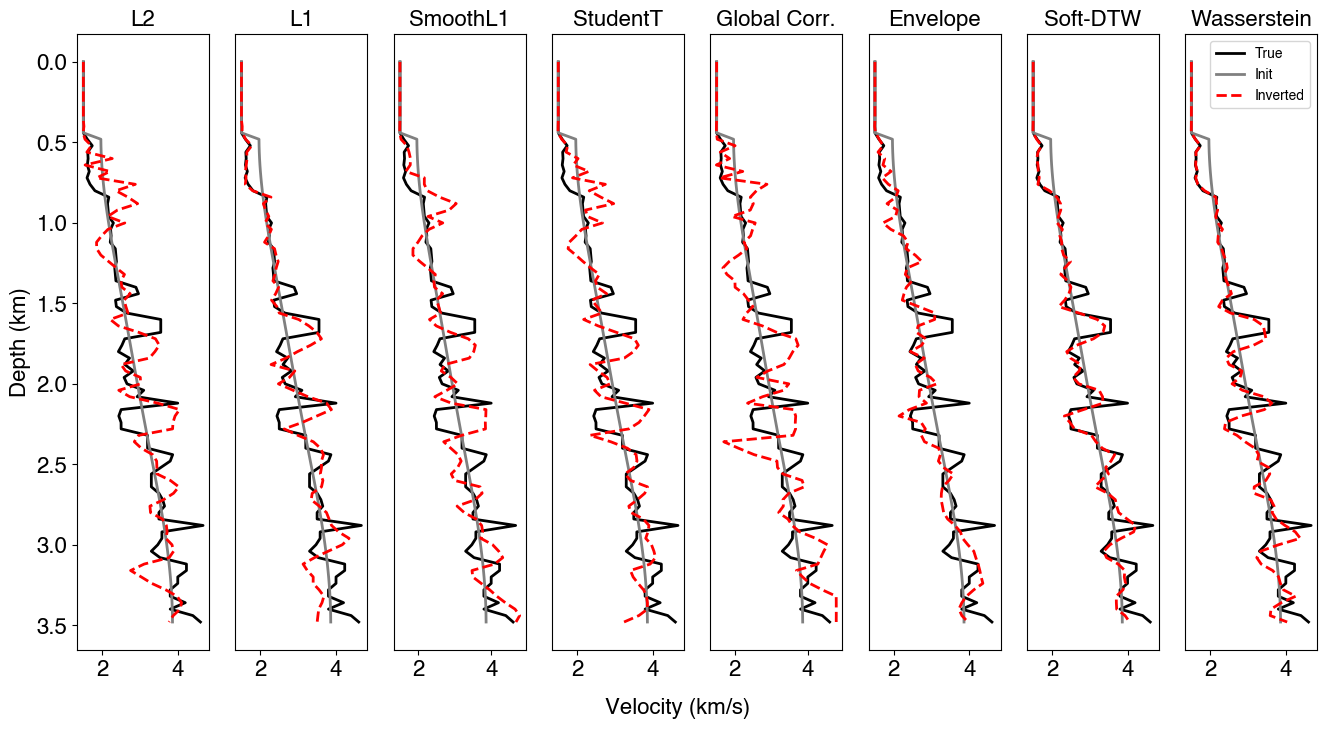

In [26]:
fig,axs = plt.subplots(1,8,figsize=(16,8))
x_distance = 4000
plot_vel_singleline_for_all(axs[0],true_v,init_v,L2_v                   ,x_distance=x_distance,title=r"L2"          , show_ylabel=True )
plot_vel_singleline_for_all(axs[1],true_v,init_v,L1_v                   ,x_distance=x_distance,title=r"L1"          , show_ylabel=False)
plot_vel_singleline_for_all(axs[2],true_v,init_v,SmoothL1_v             ,x_distance=x_distance,title=r"SmoothL1"    , show_ylabel=False)
plot_vel_singleline_for_all(axs[3],true_v,init_v,StudentT_v             ,x_distance=x_distance,title=r"StudentT"    , show_ylabel=False)
plot_vel_singleline_for_all(axs[4],true_v,init_v,CG_v                   ,x_distance=x_distance,title=r"Global Corr.", show_ylabel=False)
plot_vel_singleline_for_all(axs[5],true_v,init_v,Envelope_v             ,x_distance=x_distance,title=r"Envelope"    , show_ylabel=False)
plot_vel_singleline_for_all(axs[6],true_v,init_v,Softdtw_v              ,x_distance=x_distance,title=r"Soft-DTW"    , show_ylabel=False)
plot_vel_singleline_for_all(axs[7],true_v,init_v,Wasserstein_sinkhorn_v ,x_distance=x_distance,title=r"Wasserstein", show_ylabel=False,show_legend=True)

axs[0].set_ylabel("Depth (km)",fontsize=16)
fig.text(0.5, 0.03, 'Velocity (km/s)', ha='center',fontsize=16)


plt.savefig(os.path.join(base_path,"TestWithDiffMisfit-smooth=12-xdistance=4000.png"),dpi=300,bbox_inches='tight')
plt.show()

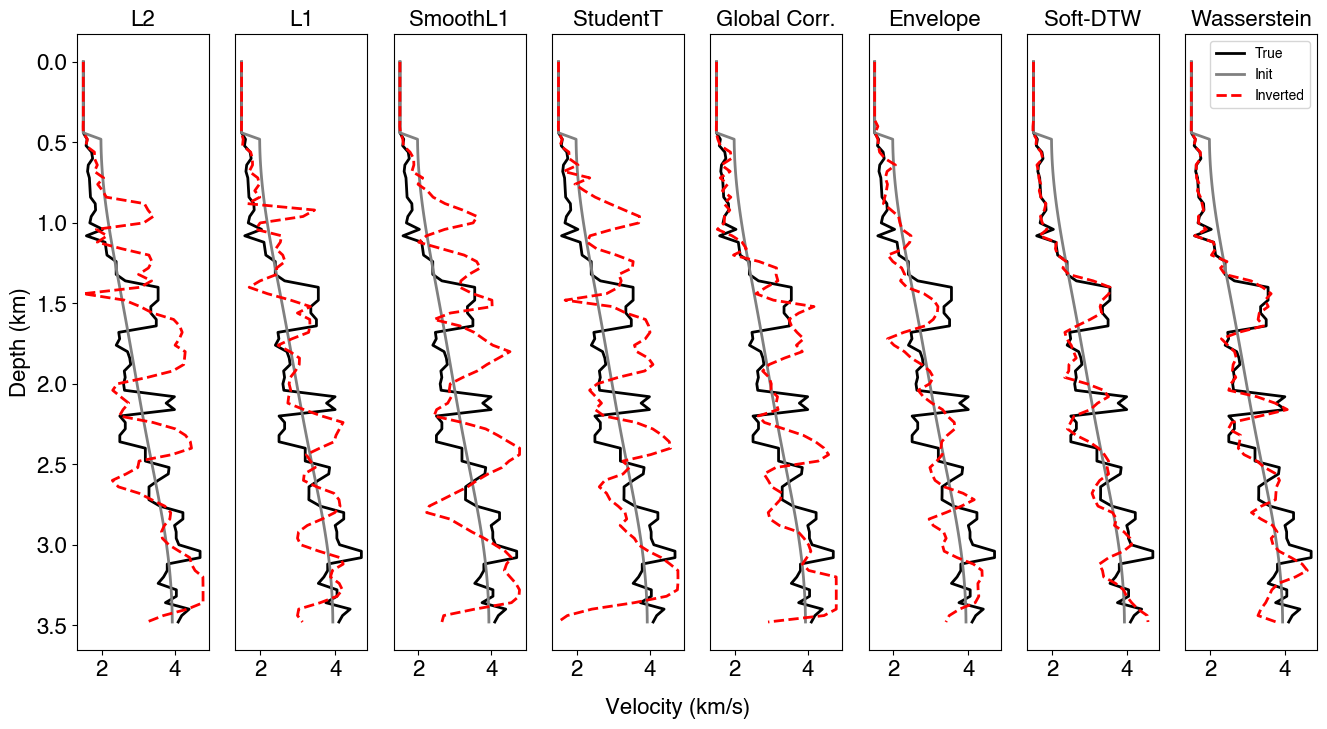

In [27]:
fig,axs = plt.subplots(1,8,figsize=(16,8))
x_distance = 5500
plot_vel_singleline_for_all(axs[0],true_v,init_v,L2_v                   ,x_distance=x_distance,title=r"L2"          , show_ylabel=True )
plot_vel_singleline_for_all(axs[1],true_v,init_v,L1_v                   ,x_distance=x_distance,title=r"L1"          , show_ylabel=False)
plot_vel_singleline_for_all(axs[2],true_v,init_v,SmoothL1_v             ,x_distance=x_distance,title=r"SmoothL1"    , show_ylabel=False)
plot_vel_singleline_for_all(axs[3],true_v,init_v,StudentT_v             ,x_distance=x_distance,title=r"StudentT"    , show_ylabel=False)
plot_vel_singleline_for_all(axs[4],true_v,init_v,CG_v                   ,x_distance=x_distance,title=r"Global Corr.", show_ylabel=False)
plot_vel_singleline_for_all(axs[5],true_v,init_v,Envelope_v             ,x_distance=x_distance,title=r"Envelope"    , show_ylabel=False)
plot_vel_singleline_for_all(axs[6],true_v,init_v,Softdtw_v              ,x_distance=x_distance,title=r"Soft-DTW"    , show_ylabel=False)
plot_vel_singleline_for_all(axs[7],true_v,init_v,Wasserstein_sinkhorn_v ,x_distance=x_distance,title=r"Wasserstein", show_ylabel=False,show_legend=True)

axs[0].set_ylabel("Depth (km)",fontsize=16)
fig.text(0.5, 0.03, 'Velocity (km/s)', ha='center',fontsize=16)


plt.savefig(os.path.join(base_path,"TestWithDiffMisfit-smooth=12-xdistance=5500.png"),dpi=300,bbox_inches='tight')
plt.show()